# Исследовние интернет-магазин «В один клик»

## Описание проекта
Интернет-магазин «В один клик» продаёт разные товары: для детей, для дома, мелкую бытовую технику, косметику и даже продукты. Отчёт магазина за прошлый период показал, что активность покупателей начала снижаться. Привлекать новых клиентов уже не так эффективно: о магазине и так знает большая часть целевой аудитории. Возможный выход — удерживать активность постоянных клиентов. Сделать это можно с помощью персонализированных предложений.
«В один клик» — современная компания, поэтому её руководство не хочет принимать решения просто так — только на основе анализа данных и бизнес-моделирования. У компании есть небольшой отдел цифровых технологий, и вам предстоит побыть в роли стажёра в этом отделе. 

**Цель проекта:** Разработать решение, которое позволит персонализировать предложения постоянным клиентам, чтобы увеличить их покупательскую активность.

## Описание данных

**market_file.csv**  
Таблица, которая содержит данные о поведении покупателя на сайте, о коммуникациях с покупателем и его продуктовом поведении.
* id — номер покупателя в корпоративной базе данных.
* Покупательская активность — рассчитанный класс покупательской активности (целевой признак): «снизилась» или «прежний уровень».
* Тип сервиса — уровень сервиса, например «премиум» и «стандарт».
* Разрешить сообщать — информация о том, можно ли присылать покупателю дополнительные предложения о товаре. Согласие на это даёт покупатель.
* Маркет_актив_6_мес — среднемесячное значение маркетинговых коммуникаций компании, которое приходилось на покупателя за последние 6 месяцев. Это значение показывает, какое число рассылок, звонков, показов рекламы и прочего приходилось на клиента.
* Маркет_актив_тек_мес — количество маркетинговых коммуникаций в текущем месяце.
* Длительность — значение, которое показывает, сколько дней прошло с момента регистрации покупателя на сайте.
* Акционные_покупки — среднемесячная доля покупок по акции от общего числа покупок за последние 6 месяцев.
* Популярная_категория — самая популярная категория товаров у покупателя за последние 6 месяцев.
* Средний_просмотр_категорий_за_визит — показывает, сколько в среднем категорий покупатель просмотрел за визит в течение последнего месяца.
* Неоплаченные_продукты_штук_квартал — общее число неоплаченных товаров в корзине за последние 3 месяца.
* Ошибка_сервиса — число сбоев, которые коснулись покупателя во время посещения сайта.
* Страниц_за_визит — среднее количество страниц, которые просмотрел покупатель за один визит на сайт за последние 3 месяца.

**market_money.csv**  
Таблица с данными о выручке, которую получает магазин с покупателя, то есть сколько покупатель всего потратил за период взаимодействия с сайтом.
* id — номер покупателя в корпоративной базе данных.
* Период — название периода, во время которого зафиксирована выручка. Например, 'текущий_месяц' или 'предыдущий_месяц'.
* Выручка — сумма выручки за период.

**market_time.csv**  
Таблица с данными о времени (в минутах), которое покупатель провёл на сайте в течение периода.
* id — номер покупателя в корпоративной базе данных.
* Период — название периода, во время которого зафиксировано общее время.
* минут — значение времени, проведённого на сайте, в минутах.

**money.csv**  
Таблица с данными о среднемесячной прибыли покупателя за последние 3 месяца: какую прибыль получает магазин от продаж каждому покупателю.
* id — номер покупателя в корпоративной базе данных.
* Прибыль — значение прибыли.

## Установка библиотек и инструментов

In [1]:
!pip install shap -q
!pip install scikit-learn==1.1.3 -q
import shap 
import pandas as pd
import numpy as np 
from scipy import stats as st 
from matplotlib import pyplot as plt
import seaborn as sns 
import sklearn
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, recall_score, precision_score, roc_auc_score
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer 
from sklearn.feature_selection import SelectKBest, f_classif
import warnings
warnings.filterwarnings("ignore")

# Обозначение констант
RANDOM_STATE = 42
TEST_SIZE = 0.25

## Загрузка данных

In [2]:
market = pd.read_csv('/datasets/market_file.csv')
display(market.info())
display(market.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   Покупательская активность            1300 non-null   object 
 2   Тип сервиса                          1300 non-null   object 
 3   Разрешить сообщать                   1300 non-null   object 
 4   Маркет_актив_6_мес                   1300 non-null   float64
 5   Маркет_актив_тек_мес                 1300 non-null   int64  
 6   Длительность                         1300 non-null   int64  
 7   Акционные_покупки                    1300 non-null   float64
 8   Популярная_категория                 1300 non-null   object 
 9   Средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  Неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 11  Ошибка_сервиса                

None

,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандартт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандартт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2


In [3]:
market_money = pd.read_csv('/datasets/market_money.csv')
display(market_money.info())
display(market_money.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       3900 non-null   int64  
 1   Период   3900 non-null   object 
 2   Выручка  3900 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 91.5+ KB


None

,id,Период,Выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6


In [4]:
market_time = pd.read_csv('/datasets/market_time.csv')
display(market_time.info())
display(market_time.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2600 non-null   int64 
 1   Период  2600 non-null   object
 2   минут   2600 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 61.1+ KB


None

,id,Период,минут
0,215348,текущий_месяц,14
1,215348,предыдцщий_месяц,13
2,215349,текущий_месяц,10
3,215349,предыдцщий_месяц,12
4,215350,текущий_месяц,13


In [5]:
money = pd.read_csv('/datasets/money.csv', sep=';', decimal=',')
display(money.info())
display(money.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       1300 non-null   int64  
 1   Прибыль  1300 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 20.4 KB


None

,id,Прибыль
0,215348,0.98
1,215349,4.16
2,215350,3.13
3,215351,4.87
4,215352,4.21


**Вывод:**  
* Во всех таблицах пропуски не обнаружены;
* Во всех таблицах корректно обозначен тип данных;
* Требуется проверка на явные и неявные дубликаты;
* Можно привести все названия столбцов к нижнему регистру и использовать аббривеатуры для сокращения длинны текста названия.

## Предобработка данных

### Изменение названия столбцов.

In [6]:
market = market.rename(columns={'Покупательская активность':'активность',
                                'Тип сервиса':'сервис', 
                                'Разрешить сообщать':'рассылка', 
                                'Маркет_актив_6_мес':'актив_6_мес', 
                                'Маркет_актив_тек_мес':'актив_тек_мес', 
                                'Длительность':'длительность', 
                                'Акционные_покупки':'акции', 
                                'Популярная_категория':'категория', 
                                'Средний_просмотр_категорий_за_визит':'просмотр_за_визит', 
                                'Неоплаченные_продукты_штук_квартал':'неоплачено_штук', 
                                'Ошибка_сервиса':'ошибки', 
                                'Страниц_за_визит':'страницы'})

market_money = market_money.rename(columns={'Период': 'период', 
                                  'Выручка': 'выручка'})

market_time = market_time.rename(columns={'Период':'период', 
                            'минут':'минуты'})

money = money.rename(columns={'Прибыль':'прибыль'})

display(market.columns, market_money.columns, market_time.columns, money.columns)

Index(['id', 'активность', 'сервис', 'рассылка', 'актив_6_мес',
       'актив_тек_мес', 'длительность', 'акции', 'категория',
       'просмотр_за_визит', 'неоплачено_штук', 'ошибки', 'страницы'],
      dtype='object')

Index(['id', 'период', 'выручка'], dtype='object')

Index(['id', 'период', 'минуты'], dtype='object')

Index(['id', 'прибыль'], dtype='object')

### Проверка и удаление дубликатов.

In [7]:
display(market.duplicated().sum())
display(market_money.duplicated().sum())
display(market_time.duplicated().sum())
display(money.duplicated().sum())

0

0

0

0

**Вывод:**  
* Были изменены названия столбцов;
* Также было проанализированно - явных дубликатов нет.

## Исследовательский анализ данных

### Количественные факторы функция.

In [8]:
def hist_box(data, column):
    """
    Отображает гистограмму и диаграмму размаха для указанного столбца данных, 
    используя более приятный визуальный стиль.
    """

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))  
    sns.histplot(data[column], ax=axes[0], kde=True, color='skyblue', edgecolor='black') 
    axes[0].set_title(f'Гистограмма "{column}"', fontsize=14)
    axes[0].set_xlabel(column, fontsize=12)
    axes[0].set_ylabel('Плотность', fontsize=12) 
    sns.boxplot(x=data[column], ax=axes[1], color='lightcoral') 
    axes[1].set_title(f'Диаграмма размаха "{column}"', fontsize=14) 
    axes[1].set_xlabel(column, fontsize=12) 
    plt.tight_layout()  
    plt.show()

In [9]:
def bar_plot(data, column):
    """
    Отображает столбчатую диаграмму для указанного столбца данных.
    """
    value_counts = data[column].value_counts()

    plt.figure(figsize=(12, 5)) 
    value_counts.plot(kind='bar', color='skyblue', edgecolor='black') 
    plt.title(f'Столбчатая диаграмма "{column}"', fontsize=14)
    plt.xlabel(column, fontsize=12)  
    plt.ylabel('Количество', fontsize=12)
    plt.xticks(rotation=0, ha='right')  
    plt.tight_layout() 
    plt.show()

#### Исследовательский анализ количественных факторов таблицы market.

In [10]:
num_col_market = ['актив_6_мес', 'длительность', 'акции']

In [11]:
dis_col_market = ['актив_тек_мес', 'просмотр_за_визит','неоплачено_штук', 'ошибки', 'страницы']

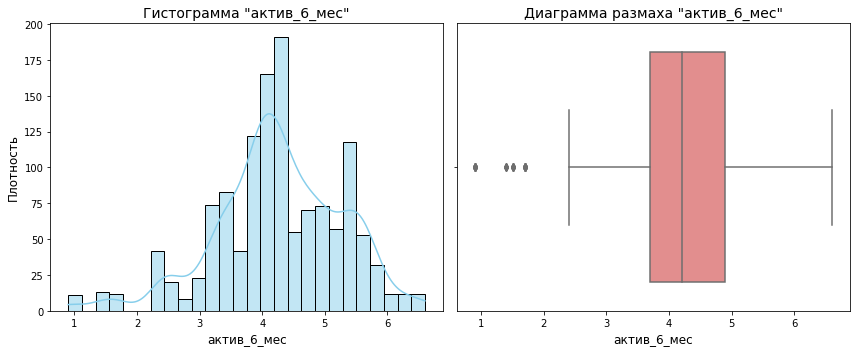

None

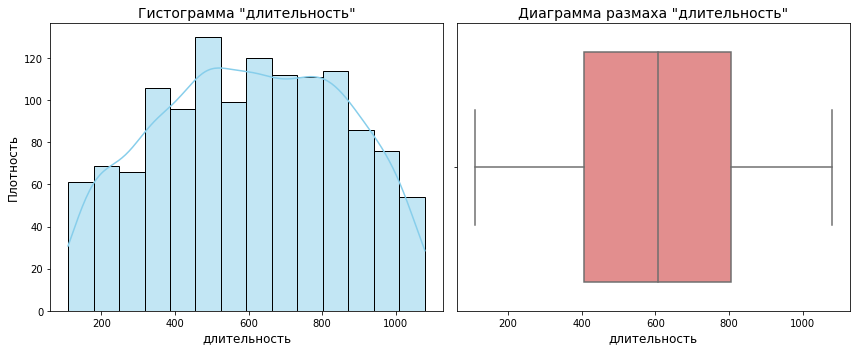

None

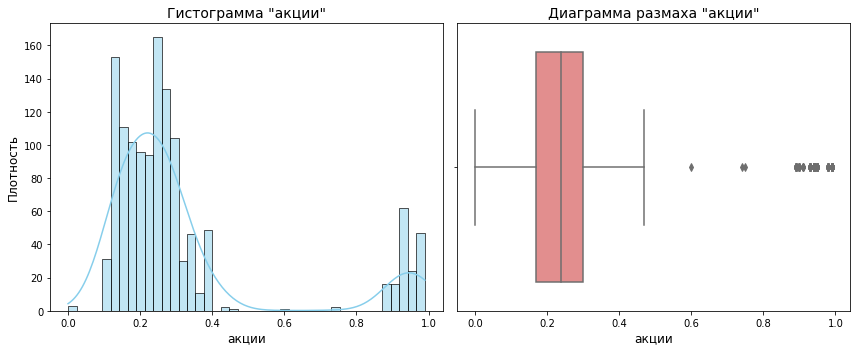

None

In [12]:
for name in num_col_market:
    display(hist_box(market, name))

*Промежуточный вывод:*  
* фактор **актив_6_мес** имеет близкое распределение к нормальному. Присутствуют выбросы, которые возможно нужно удалить;
* фактор **длительность** не имеет выбросов, имеет близкое распределение к равномерному;
* фактор **акции** имеет бимодальное распределение, также можно отметить, что есть покупатели, которые без акций не покупают.

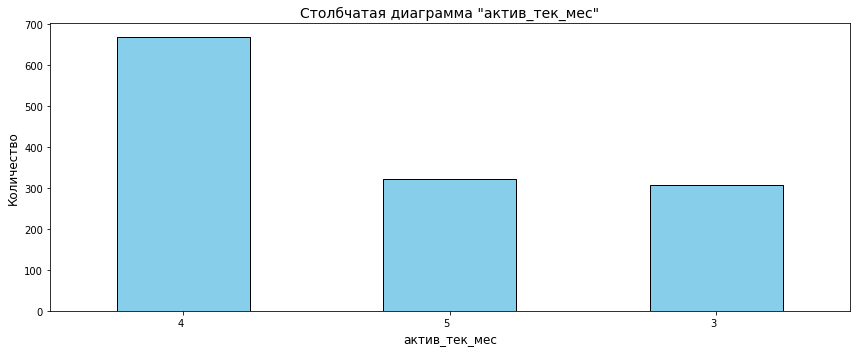

None

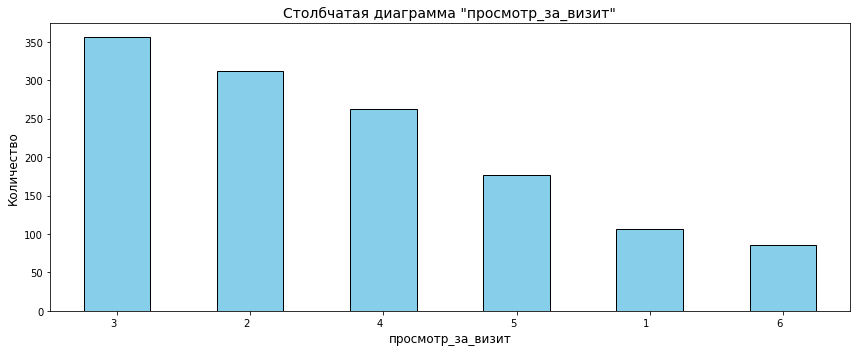

None

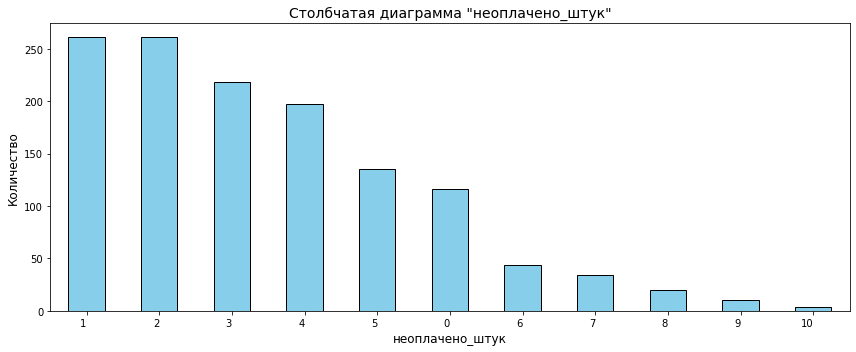

None

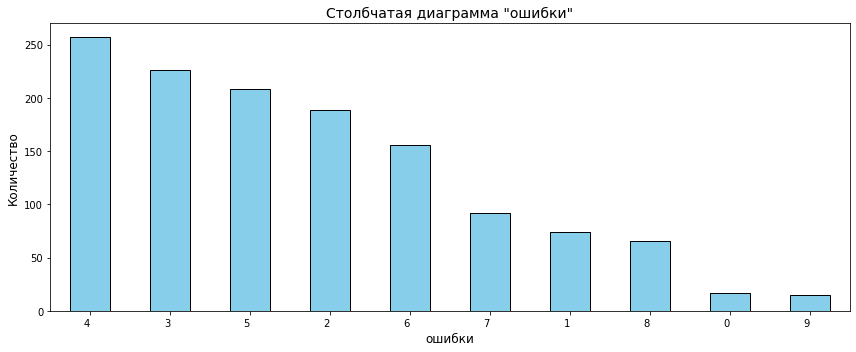

None

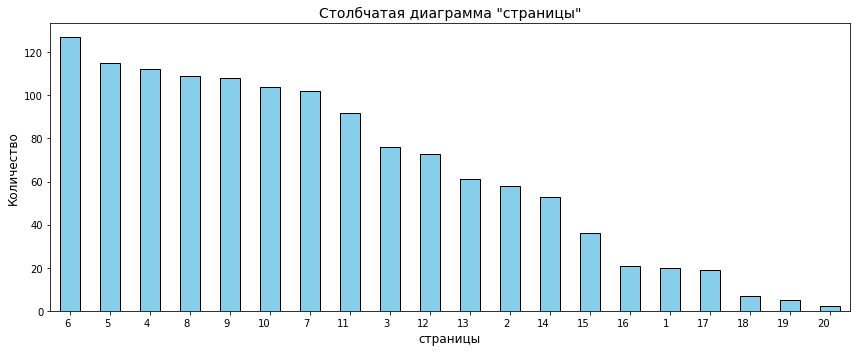

None

In [13]:
for name in dis_col_market:
    display(bar_plot(market, name))

*Промежуточный вывод:*  
* фактор **актив_тек_мес** судя по визуализации нужно перевести в категориальный, где будет три категории;
* фактор **просмотр_за_визит** судя по визуализации нужно перевести в категориальный, где будет 6 категорий;
* фактор **неоплачено_штук** судя по визуализации нужно перевести в категориальный, где будет 11 категорий. Чаще всего неоплачены 1 или 2 товара;
* фактор **ошибки** судя по визуализации нужно перевести в категориальный, где будет 10 категорий;
* фактор **страницы** не имеет выбросов, имеет слегка сдвинутое влево нормальное распределение. Средний пользователь чаще всего просматривает 6 страниц.

#### Исследовательский анализ количественных факторов таблицы market_money.

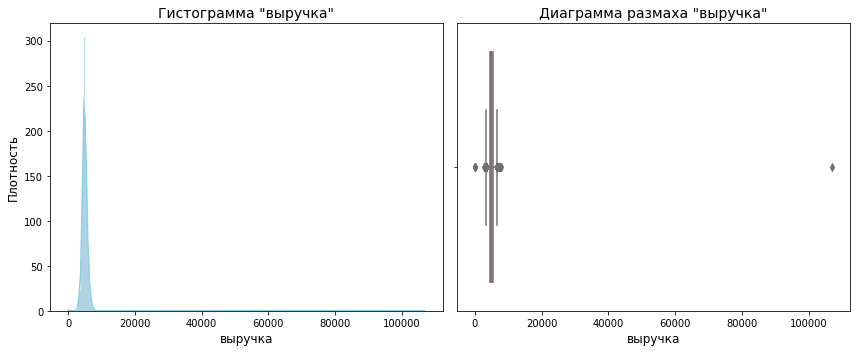

None

In [14]:
display(hist_box(market_money, 'выручка'))

Пристутсвует выброс, который мешает изучению фактора.

In [15]:
display(market_money.query('выручка > 15000'))

,id,период,выручка
98,215380,текущий_месяц,106862.2


Выброс один, его нужно убрать, также убрать пользователя к которому он относится из всех датасетов, так как скорее всего это выручка за месяц, который не завершился.

In [16]:
market_money = market_money.query('выручка < 15000')

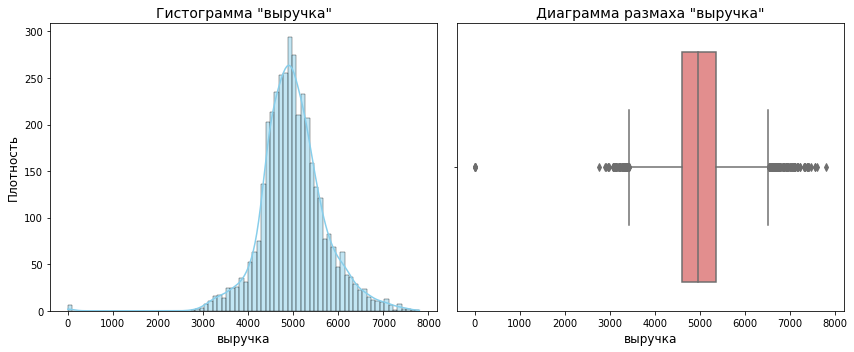

None

In [17]:
display(hist_box(market_money, 'выручка'))

*Промежуточный вывод:*  
Выручка имеет распределение близкое к нормальному, также имеются выбросы - пользователи без покупок. В будущем их надо будет исключить.

#### Исследовательский анализ количественных факторов таблицы market_time.

In [18]:
def hist_sturges(data, column):
    """
    Отображает гистограмму для указанного столбца данных, используя правило Стерджеса
    для определения количества бинов.
    """
    n_sturges = int(np.log2(len(data[column]))) + 1
    plt.figure(figsize=(10, 6))  
    sns.histplot(data[column], kde=True, color='skyblue', edgecolor='black', bins=n_sturges)
    plt.title(f'Гистограмма "{column}" (Правило Стерджеса, bins={n_sturges})', fontsize=14) 
    plt.xlabel(column, fontsize=12)  
    plt.ylabel('Плотность', fontsize=12)  
    plt.tight_layout()
    plt.show()  

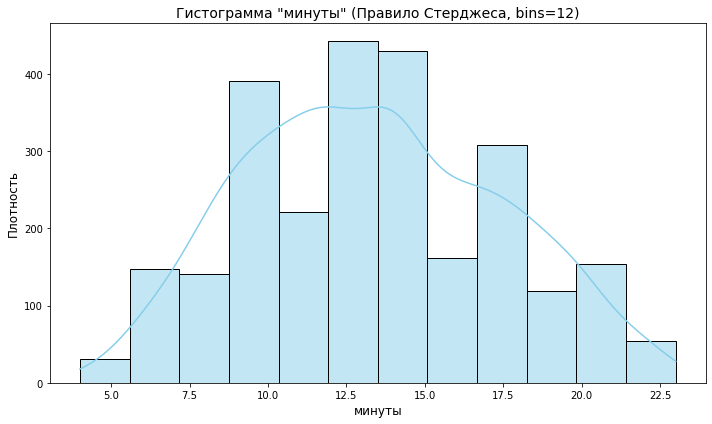

None

In [19]:
display(hist_sturges(market_time, 'минуты'))

*Промежуточный вывод:*  
Фактор **минуты** имеет близкое к нормальному распределение, выбросов нет.

#### Исследовательский анализ количественных факторов таблицы money.

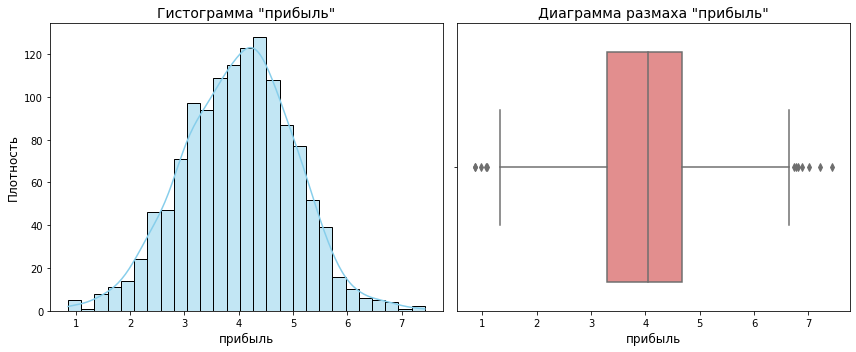

None

In [20]:
display(hist_box(money, 'прибыль'))

*Промежуточный вывод:*  
Фактор **прибыль** имеет распределение близкое к нормальному, также присутствуют незначительные выбросы.

### Категориальные факторы функция.

In [21]:
def pie_graph(dataset, column, name):
    """
    Создает круговую диаграмму для визуализации распределения категориального столбца.
    Графики выводятся один за другим.
    """

    plt.figure(figsize=(8, 8))  
    plt.title(column, fontsize=14) 
    counts = dataset.groupby(column)[name].count()

    plt.pie(counts,
            autopct='%1.1f%%',             
            startangle=90,             
            colors=sns.color_palette('Pastel1'),  
            explode=[0.02] * len(counts),  
            wedgeprops={'linewidth': 1, 'edgecolor': 'white'},
            textprops={'fontsize': 10},     
            pctdistance=0.85)            

    plt.legend(counts.index,
               title=column,
               loc="center left",
               bbox_to_anchor=(1, 0, 0.5, 1))

    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(centre_circle)
    plt.tight_layout() 
    plt.show()  

#### Исследовательский анализ категориальных факторов таблицы market.

In [22]:
cat_col_market = ['активность', 'сервис', 'рассылка', 'категория']

In [ ]:
for name in cat_col_market:
    display(pie_graph(market, name, 'id'))

In [24]:
market['сервис'] = market['сервис'].replace('стандартт', 'стандарт')
market['категория'] = market['категория'].replace('Косметика и аксесуары', 'Косметика и аксессуары')

*Промежуточный вывод:*  
* Сразу видна несбаланнсированость каждого из факторов.
* Была произведена замена стандартт на стандарт. Так как это явно одна категория

#### Исследовательский анализ категориальных факторов таблицы market_money.

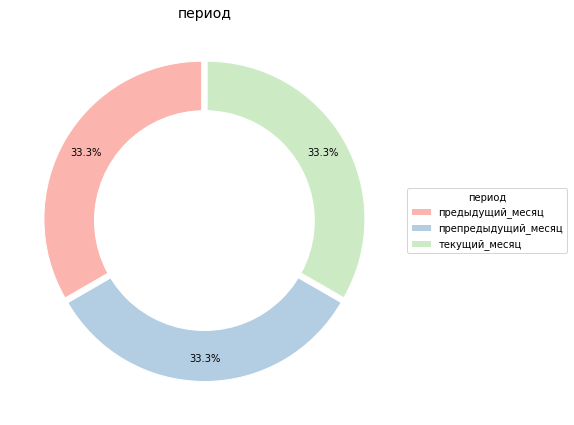

None

In [25]:
display(pie_graph(market_money, 'период', 'id'))

*Промежуточный вывод:*  
Фактор сбалансирован, названия в норме.

#### Исследовательский анализ категориальных факторов таблицы market_time.

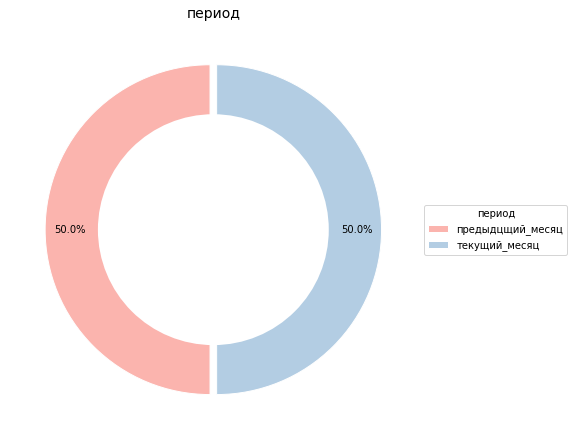

None

In [26]:
display(pie_graph(market_time, 'период', 'id'))

*Промежуточный вывод:*  
Фактор сбалансирован, однако названия не в норме, нужно подправить.

In [27]:
market_time['период'] = market_time['период'].replace('предыдцщий_месяц', 'предыдущий_месяц')


### Удаление неактивных пользователей

In [28]:
market_money.query('выручка == 0')

,id,период,выручка
0,215348,препредыдущий_месяц,0.0
2,215348,предыдущий_месяц,0.0
28,215357,препредыдущий_месяц,0.0
29,215357,предыдущий_месяц,0.0
34,215359,предыдущий_месяц,0.0
35,215359,препредыдущий_месяц,0.0


In [29]:
market = market.query('id != [215348, 215357, 215359, 215380]')
market_money = market_money.query('id != [215348, 215357, 215359, 215380]')
market_time = market_time.query('id != [215348, 215357, 215359, 215380]')
money = money.query('id != [215348, 215357, 215359, 215380]')

## Объединение таблиц

In [30]:
market_money_period = ['препредыдущий_месяц', 'предыдущий_месяц', 'текущий_месяц'] 

for name in market_money_period:
    market = market.merge(market_money.query('период == @name'), on='id', how='left', suffixes=('_препред', '_пред'))
    
market = market.drop(labels=['период_препред', 'период_пред', 'период'], axis=1)
market = market.rename(columns={'выручка':'выручка_тек'})
display(market.head())

,id,активность,сервис,рассылка,актив_6_мес,актив_тек_мес,длительность,акции,категория,просмотр_за_визит,неоплачено_штук,ошибки,страницы,выручка_препред,выручка_пред,выручка_тек
0,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,4472.0,5216.0,4971.6
1,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,4826.0,5457.5,5058.4
2,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,4793.0,6158.0,6610.4
3,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,4594.0,5807.5,5872.5
4,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,5124.0,4738.5,5388.5


In [31]:
market_time_period = ['предыдущий_месяц', 'текущий_месяц'] 

for name in market_time_period:
    market = market.merge(market_time.query('период == @name'), on='id', how='left', suffixes=('_пред', '_тек'))
    
market = market.drop(labels=['период_пред', 'период_тек'], axis=1)
display(market.head())

,id,активность,сервис,рассылка,актив_6_мес,актив_тек_мес,длительность,акции,категория,просмотр_за_визит,неоплачено_штук,ошибки,страницы,выручка_препред,выручка_пред,выручка_тек,минуты_пред,минуты_тек
0,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,4472.0,5216.0,4971.6,12,10
1,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,4826.0,5457.5,5058.4,8,13
2,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,4793.0,6158.0,6610.4,11,13
3,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,4594.0,5807.5,5872.5,8,11
4,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,5124.0,4738.5,5388.5,10,10


*Промежуточный вывод:*  
Таблицы были объединены.

### Исследовательский анализ объединённой таблицы.

In [32]:
def hist_box_graph_two(dataset, column):
    """
    Отображает гистограмму и диаграмму размаха для указанного столбца данных,
    с разделением по категории 'активность', используя улучшенный визуальный стиль.
    """

    fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
    sns.histplot(data=dataset, x=column, hue='активность', kde=True, palette='magma', ax=axes[0], element="step") 
    axes[0].set_title(f'Гистограмма "{column}" по активности', fontsize=14)
    axes[0].set_xlabel(f'Значение фактора "{column}"', fontsize=12)
    axes[0].set_ylabel('Плотность', fontsize=12)
    axes[0].grid(axis='y', alpha=0.5)
    
    sns.boxplot(x='активность', y=column, data=dataset, palette='magma', ax=axes[1])
    axes[1].set_title(f'Диаграмма размаха "{column}" по активности', fontsize=14)
    axes[1].set_xlabel('Активность', fontsize=12)
    axes[1].set_ylabel(f'Значение фактора "{column}"', fontsize=12)
    axes[1].grid(axis='y', alpha=0.5) 
    plt.tight_layout() 
    plt.show()

In [33]:
def bar_plot_by_activity(dataset, column):
    """
    Отображает столбчатую диаграмму для указанного столбца данных,
    с разделением по категории 'активность'.  Легенда сбоку, график больше.
    """
    grouped_data = dataset.groupby('активность')[column].value_counts().unstack()

    plt.figure(figsize=(18, 8))  
    ax = grouped_data.plot(kind='bar', stacked=False, colormap='viridis', ax=plt.gca())  
    plt.title(f'Столбчатая диаграмма "{column}" по активности', fontsize=16)
    plt.xlabel('Активность', fontsize=14)
    plt.ylabel('Количество', fontsize=14)
    plt.xticks(rotation=0, fontsize=12)  
    plt.yticks(fontsize=12)  
    plt.legend(title=column, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12) 
    plt.tight_layout(rect=[0, 0, 0.85, 1])  
    plt.show()

In [34]:
num_col_market = ['актив_6_мес', 'длительность', 'акции', 'выручка_препред', 'выручка_пред', 
                  'выручка_тек']

In [35]:
dis_col_market = ['актив_тек_мес', 'просмотр_за_визит','неоплачено_штук', 'ошибки', 
                  'страницы', 'минуты_пред', 'минуты_тек']

In [ ]:
for name in num_col_market:
    display(hist_box_graph_two(market, name))

In [ ]:
for name in dis_col_market:
    display(bar_plot_by_activity(market, name))

*Промежуточный вывод:*
* факторы **актив_6_мес**, **просмотр_за_визит**, **страницы**, **выручка_препред**, **минуты_пред** и **минуты_тек** в среднем больше у покупателей с прежним уровнем активности, чем у тех у кого снизилась;
* факторы **акции**, **неоплачено_штук** в среднем ниже у покупателей с прежним уровнем активности, чем у тех у кого снизилась активность.

In [38]:
def pie_graph_two(dataset, column):
    """
    Создает две круговые диаграммы для визуализации распределения категориального столбца 'column'
    в зависимости от активности ("Снизилась" и "Прежний уровень").
    """

    plt.figure(figsize=(14, 6))  
    plt.subplot(1, 2, 1)
    plt.title(f'Фактор "{column}"\nПокупательная активность - Снизилась', fontsize=12)
    counts_снизилась = dataset[dataset['активность'] == 'Снизилась'].groupby(column)['id'].count()

    if not counts_снизилась.empty:
        plt.pie(counts_снизилась,
                autopct='%1.1f%%',
                startangle=90,
                colors=sns.color_palette('Pastel1'), 
                wedgeprops={'linewidth': 1, 'edgecolor': 'white'}, 
                textprops={'fontsize': 10},
                pctdistance=0.85,
                labels=counts_снизилась.index)
        plt.ylabel('')
    else:
        plt.text(0.5, 0.5, 'Нет данных', ha='center', va='center', fontsize=12)

    plt.subplot(1, 2, 2)
    plt.title(f'Фактор "{column}"\nПокупательная активность - Прежний уровень', fontsize=12)
    counts_прежний = dataset[dataset['активность'] != 'Снизилась'].groupby(column)['id'].count()

    if not counts_прежний.empty:
        plt.pie(counts_прежний,
                autopct='%1.1f%%',
                startangle=90,
                colors=sns.color_palette('Pastel1'),  
                wedgeprops={'linewidth': 1, 'edgecolor': 'white'}, 
                textprops={'fontsize': 10},
                pctdistance=0.85,
                labels=counts_прежний.index)
        plt.ylabel('')
    else:
        plt.text(0.5, 0.5, 'Нет данных', ha='center', va='center', fontsize=12)

    plt.tight_layout()
    plt.show()

In [39]:
cat_col_market = ['сервис', 'рассылка', 'категория']

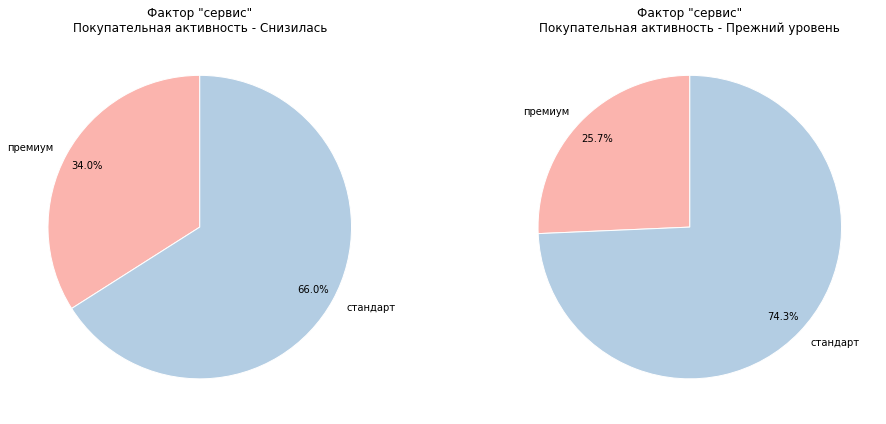

None

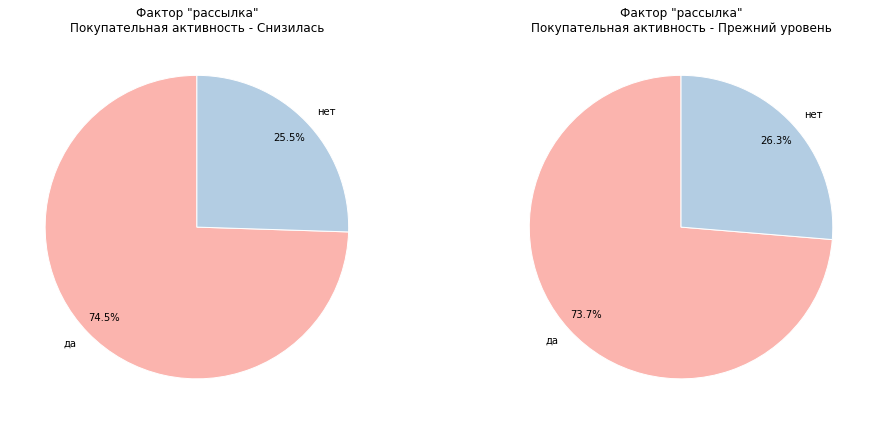

None

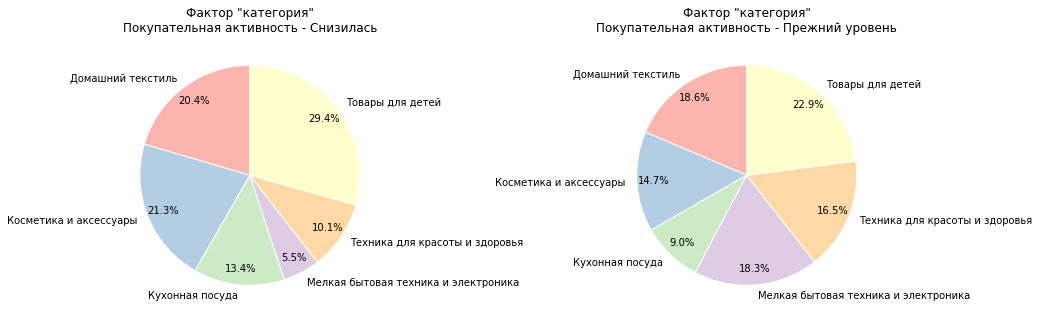

None

In [40]:
for name in cat_col_market:
    display(pie_graph_two(market, name))

*Промежуточный вывод:*  
Соотношение категорий в рассматриваемых факторах практически не изменилось. Самые большие изменения произошли в факторе "категория". При прежней покупательной активности соотношение более равномерное, при снижении покупательной активности основными категориями становятся товары для детей, косметика и аксессуары, домашний текстиль.

## Корреляционный анализ

In [41]:
def normality_test(data, features, alpha=0.05):
    """
    Проводит тест на нормальность распределения для заданных признаков.
    """
    results = []
    for feature in features:
        # Тест Шапиро-Уилка
        statistic, p_value = st.shapiro(data[feature])
        is_normal = p_value > alpha

        results.append({
            'feature': feature,
            'statistic': statistic,
            'p_value': p_value,
            'is_normal': is_normal
        })
    return pd.DataFrame(results)

In [42]:
results_df = normality_test(market, num_col_market)
display(results_df)

,feature,statistic,p_value,is_normal
0,актив_6_мес,0.978031,3.778058e-13,False
1,длительность,0.972601,5.744778e-15,False
2,акции,0.657736,4.203895e-45,False
3,выручка_препред,0.986371,1.155594e-09,False
4,выручка_пред,0.990200,1.309214e-07,False
5,выручка_тек,0.994703,1.533084e-04,False


При анализе будем использовать коэффициент корреляции Спирмана, так как имеются дискретные факторы, выбросы, скосы, ассиметрии.

In [43]:
def красивый_корреляционный_график(df):
    """
    Создает красивую и информативную корреляционную матрицу на основе коэффициента Спирман.
    """
    numeric_df = df.select_dtypes(include=np.number)
    if 'id' in numeric_df.columns:
        numeric_df = numeric_df.drop('id', axis=1)

    corr = numeric_df.corr(method='spearman') 
    mask = np.triu(np.ones_like(corr, dtype=bool))
    plt.figure(figsize=(12, 10))  
    sns.set(style="white")       
    sns.heatmap(corr,
                mask=mask,            
                cmap="magma",        
                vmax=1,                
                vmin=-1,               
                center=0,              
                square=True,           
                linewidths=.5,        
                cbar_kws={"shrink": .5}, 
                annot=True,            
                fmt=".2f",            
                annot_kws={"fontsize": 10}) 

    plt.title("Корреляционная Матрица (Спирман)", fontsize=16)
    plt.xticks(rotation=45, ha='right')  
    plt.yticks(rotation=0)            
    plt.tight_layout()              
    plt.show()

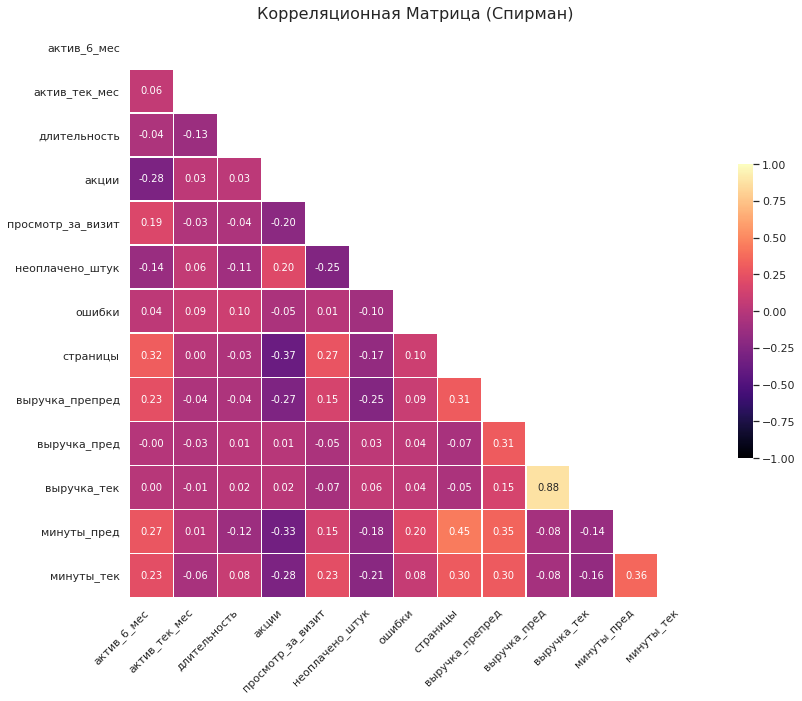

In [44]:
красивый_корреляционный_график(market)

*Промежуточный вывод:*  
Сильная корреляция наблюдается между факторами **выручка_тек** и **выручка_пред**. Убирать мы их не будем, объединим их в один столбец.

In [45]:
market['выручка_пред_тек'] = market['выручка_пред'] + market['выручка_тек']

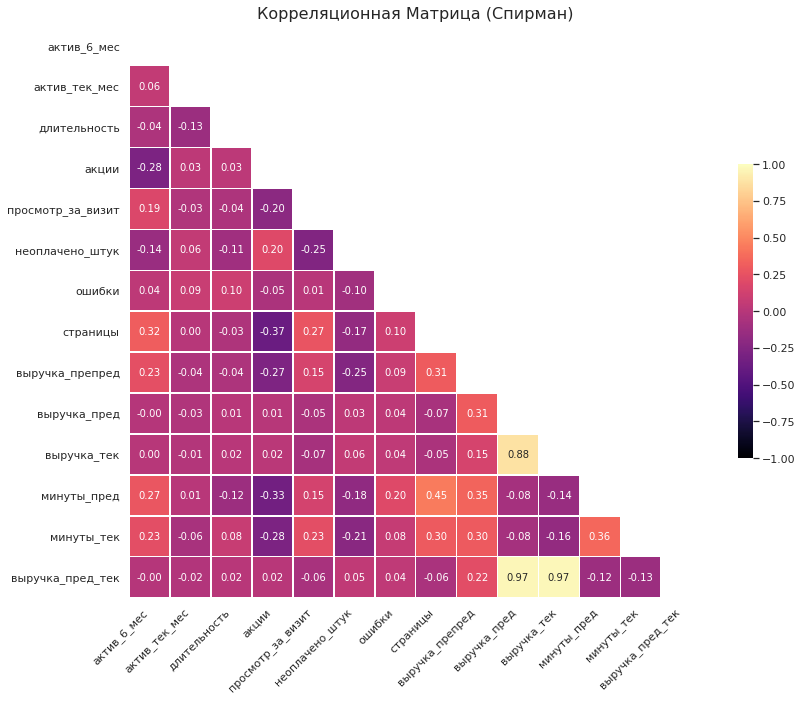

In [46]:
красивый_корреляционный_график(market)

*Промежуточный вывод:*  
Когда вы объединяете сильно коррелированные переменные, вы, по сути, создаете новую переменную, которая отражает общую информацию, содержащуюся в исходных переменных. Это устраняет избыточность и уменьшает степень линейной зависимости между предикторами в вашей модели. Новый фактор сильно коррелирован только с теми из которых он собран.

## Поиск лучшей модели

### Подготовка данных используя пайплайны.

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    market.drop(['активность','выручка_пред', 'выручка_тек', 'id'], axis=1),
    market['активность'],
    test_size = TEST_SIZE, 
    random_state = RANDOM_STATE,
    stratify = market['активность'])

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

cat_col = ['рассылка', 'категория']

ord_col = ['сервис']

num_col = ['актив_6_мес', 'длительность', 'акции','страницы', 'выручка_препред', 'выручка_пред_тек', 'минуты_пред', 
           'минуты_тек', 'актив_тек_мес','просмотр_за_визит','неоплачено_штук', 'ошибки']

# Пайплайн для кодирования категориальных признаков
ohe_pipe = Pipeline(
    [
        ('simpleImputer_ohe', 
         SimpleImputer(missing_values=np.nan, 
                       strategy='most_frequent')), 
        ('ohe', 
         OneHotEncoder(handle_unknown='ignore', 
                       sparse=False))
    ]
)

ord_pipe = Pipeline(
    [
        (
            'simple_imputer_ord_before',
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
            'ord',
            OrdinalEncoder(categories=[['премиум','стандарт']],
                          handle_unknown='use_encoded_value',
                          unknown_value=np.nan)
        ),
        (
            'simple_imputer_ord_after',
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        )
    ]
)

# Пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [
        ('ohe', ohe_pipe, cat_col),
        ('ord', ord_pipe, ord_col),
        ('num', StandardScaler(), num_col)
    ], 
    remainder='passthrough'
)

# Финальный пайплайн, объединение подготовки данных и модели
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

# Параметры для поиска оптимальной модели с разными Scaler и Encoder
param_grid = {
    'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough'], 
    'models': [DecisionTreeClassifier(random_state=RANDOM_STATE),
               KNeighborsClassifier(),
               SVC(random_state=RANDOM_STATE),
               LogisticRegression(random_state=RANDOM_STATE)]
}

# Параметры для поиска опт. модели с разными Scaler и Encoder + перебор гипер парам.
param_distributions = [
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(1, 20),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']   
    },
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 11),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
    {
        'models': [SVC(random_state=RANDOM_STATE, probability=True)],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  

    },
    {
        'models': [LogisticRegression(random_state=RANDOM_STATE)],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    }
]

### Поиск оптимальной модели не используя перебор гиперпараметров

In [48]:
grid = GridSearchCV(
    pipe_final, 
    param_grid=param_grid, 
    cv=5, 
    scoring='roc_auc', 
    n_jobs=-1
)

grid.fit(X_train, y_train)

display('Лучшая модель и её параметры:', grid.best_params_)
display('Метрика ROC-AUC для лучшей модели:', round(grid.best_score_, 6)) 

'Лучшая модель и её параметры:'

{'models': SVC(random_state=42), 'preprocessor__num': StandardScaler()}

'Метрика ROC-AUC для лучшей модели:'

0.910572

*Промежуточный вывод:*  
Без подбора гиперпараметров самая лучшая модель **{'models': SVC(random_state=42), 'preprocessor__num': StandardScaler()}** и метрика ROC-AUC для неё **0.910572**.

### Поиск оптимальной модели используя перебор гиперпараметров

In [49]:
grid_perebor = GridSearchCV(
    pipe_final, 
    param_grid=param_distributions, 
    cv=5, 
    scoring='roc_auc', 
    n_jobs=-1, 
)

grid_perebor.fit(X_train, y_train)

display('Лучшая модель и её параметры:', grid_perebor.best_params_)
display('Метрика ROC-AUC для лучшей модели:', round(grid_perebor.best_score_, 6)) 
print("-------------------------------------------")

y_pred = grid_perebor.predict_proba(X_test)
display(f'Метрика ROC-AUC на тестовой выборке: {round(roc_auc_score(y_test, y_pred[:, 1]), 6)}')

'Лучшая модель и её параметры:'

{'models': SVC(probability=True, random_state=42),
 'preprocessor__num': StandardScaler()}

'Метрика ROC-AUC для лучшей модели:'

0.910572

-------------------------------------------


'Метрика ROC-AUC на тестовой выборке: 0.911378'

*Промежуточный вывод:*  
* **Важность метрики** Выбрана метрика ROC-AUC, потому что имеется несбалансированность целевого признака. Также его легко интерпретировать.
* Снова самой лучшей моделью была выбрана {'models': SVC(probability=True, random_state=42), 'preprocessor__num': StandardScaler()} с метрикой ROC-AUC для неё 0.910572;
* На тестовой выборке результат чуть лучше 0.911378.

## Анализ важности факторов

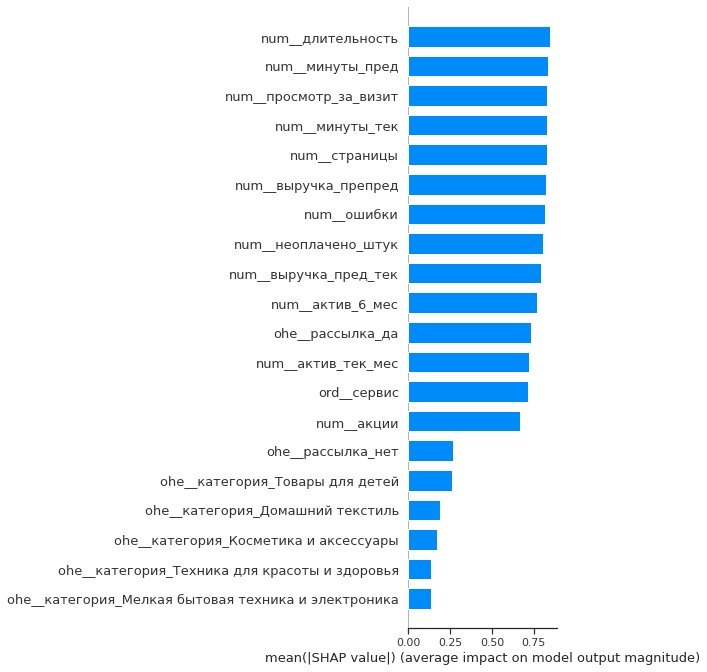

In [50]:
X_encoded_1 =  grid_perebor.best_estimator_['preprocessor'].fit_transform(X_train)
model_1 =  grid_perebor.best_estimator_['models'].fit(X_encoded_1, y_train)
explainer_1 = shap.PermutationExplainer(model_1, X_encoded_1)
labels_1 =  grid_perebor.best_estimator_[:-1].get_feature_names_out()
shap.summary_plot(X_encoded_1, plot_type='bar', feature_names=labels_1) 

*Вывод:*  
Самый важный признак **длительность** - время с момента регистрации пользователя. Далее идёт **минуты** - время проведённое на сайте и так далее, так ка важность у первых 13 не сильно отличается. Разобъём покупателей по самым важным факторам на сегменты.

## Сегментация пользователей

In [51]:
X_test['вероятность'] = y_pred[:, 1]
df = X_test.sort_values(by='вероятность')
df.head()

,сервис,рассылка,актив_6_мес,актив_тек_мес,длительность,акции,категория,просмотр_за_визит,неоплачено_штук,ошибки,страницы,выручка_препред,минуты_пред,минуты_тек,выручка_пред_тек,вероятность
485,премиум,да,4.9,3,888,0.14,Техника для красоты и здоровья,3,1,6,9,5268.0,15,18,9591.0,0.018133
885,стандарт,да,4.1,4,551,0.21,Мелкая бытовая техника и электроника,4,1,4,10,4607.0,17,13,10010.5,0.018333
1060,стандарт,да,5.5,3,847,0.11,Мелкая бытовая техника и электроника,5,1,5,4,5233.0,14,16,10578.8,0.020598
1113,стандарт,да,4.9,4,739,0.17,Мелкая бытовая техника и электроника,5,1,4,4,5180.0,18,15,11423.1,0.020749
695,премиум,да,3.9,4,572,0.14,Мелкая бытовая техника и электроника,4,2,2,6,5194.0,16,18,11958.5,0.021065


*Промежуточный вывод:* Добавил в таблицу вероятность отношения к первому классу, классу со сниженным уровнем активности.

In [52]:
num_data = ['актив_6_мес', 'актив_тек_мес', 'длительность', 'акции', 'просмотр_за_визит', 'неоплачено_штук', 
            'ошибки', 'страницы', 'выручка_препред', 'минуты_пред', 'минуты_тек', 'выручка_пред_тек']

In [53]:
num_col_1 = ['актив_6_мес', 'длительность', 'акции',  
            'выручка_препред', 'выручка_пред_тек']

In [54]:
dis_col_1 = ['актив_тек_мес', 'просмотр_за_визит', 'неоплачено_штук', 
            'ошибки', 'страницы', 'минуты_пред', 'минуты_тек']

In [55]:
def visualize_feature_probability_scatter(data, name):
    """
    Визуализирует зависимость между вероятностью принадлежности к классу 1
    и значением фактора, используя точечный график.
    """
    plt.figure(figsize=(12, 6))  
    plt.title(f'Зависимость фактора "{name}" от вероятности')
    plt.xlabel('Вероятность принадлежности к классу 1')
    plt.ylabel(f'Значение "{name}"')

    plt.scatter(x=data['вероятность'],
                y=data[name],
                alpha=0.5,        
                color='coral',  
                s=20)              
    plt.grid(True)  
    plt.show()

In [ ]:
for name in num_data:
    display(visualize_feature_probability_scatter(df, name))

*Промежуточный вывод:*  
Перечислим значения факторов свойственных для покупателей со сниженной активностью.
* 'актив_6_мес' меньше 3 месяцев;
* 'акции' больше 0.7;
* 'неоплачено_штук' 6 и более;
* 'страницы' менее 4;
* 'выручка_препред' менее 4400;
* 'минуты_пред' менее 10;
* 'минуты_тек' менее 10.

Можно выделить сегмент покупателей, которые совершают покупки на малую сумму, то есть со значениями фактора "выручка_препред" менее 4400, потому что активность таких покупателей низкая в последнее время.

In [57]:
data = df.query('выручка_препред < 4400')

In [ ]:
for name in num_col_1:
    display(hist_box(data, name))

In [ ]:
for name in dis_col_1:
    display(bar_plot(data, name))

In [60]:
cat_data = ['сервис', 'рассылка', 'категория']

In [ ]:
for name in cat_data:
    display(pie_graph(data, name, 'актив_6_мес'))

*Промежуточный вывод:*
Большинство пользуется стандартной подпиской, получает рассылку, однако акциями пользуется не большинство. В основном покупают товары для детей и технику для красоты и здоровья. Нужно им рассылать акции на товары для детей и технику для красоты и здоровья.

In [62]:
market = market.merge(money, on='id', how='left',)
display(market.head())

,id,активность,сервис,рассылка,актив_6_мес,актив_тек_мес,длительность,акции,категория,просмотр_за_визит,неоплачено_штук,ошибки,страницы,выручка_препред,выручка_пред,выручка_тек,минуты_пред,минуты_тек,выручка_пред_тек,прибыль
0,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,4472.0,5216.0,4971.6,12,10,10187.6,4.16
1,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,4826.0,5457.5,5058.4,8,13,10515.9,3.13
2,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,4793.0,6158.0,6610.4,11,13,12768.4,4.87
3,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,4594.0,5807.5,5872.5,8,11,11680.0,4.21
4,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,5124.0,4738.5,5388.5,10,10,10127.0,3.95


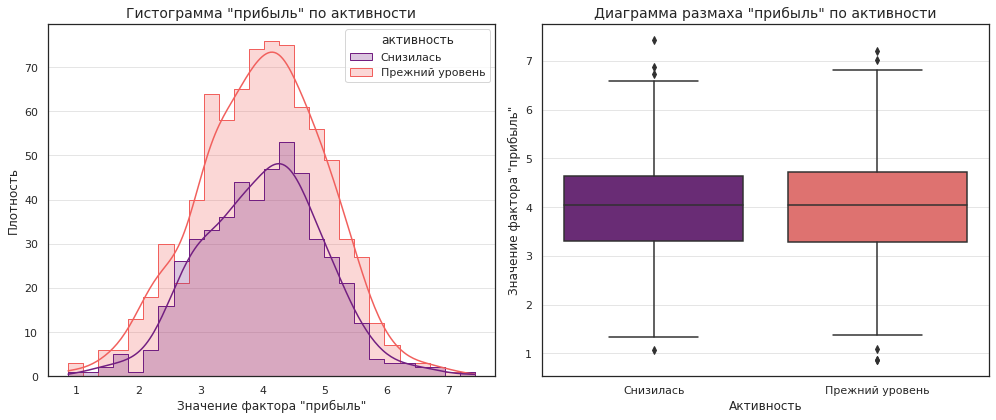

In [63]:
hist_box_graph_two(market, 'прибыль')

*Промежуточный вывод:* Сильных изменений по прибыли не наблюдается в зависимости от активности.

In [64]:
k_market = market.query('категория == "Товары для детей"')
display(k_market.head())

,id,активность,сервис,рассылка,актив_6_мес,актив_тек_мес,длительность,акции,категория,просмотр_за_визит,неоплачено_штук,ошибки,страницы,выручка_препред,выручка_пред,выручка_тек,минуты_пред,минуты_тек,выручка_пред_тек,прибыль
0,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,4472.0,5216.0,4971.6,12,10,10187.6,4.16
2,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,4793.0,6158.0,6610.4,11,13,12768.4,4.87
3,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,4594.0,5807.5,5872.5,8,11,11680.0,4.21
6,215355,Снизилась,стандарт,нет,4.7,4,284,0.17,Товары для детей,5,1,6,4,4749.0,3263.0,3772.6,12,10,7035.6,5.26
12,215363,Снизилась,стандарт,нет,4.9,4,923,0.29,Товары для детей,6,0,3,1,4633.0,6010.0,6128.3,8,5,12138.3,1.83


In [65]:
num_data_1 = ['акции', 'выручка_препред','выручка_пред','выручка_тек', 'прибыль']

In [66]:
dis_data_1 = ['просмотр_за_визит', 'неоплачено_штук', 'страницы', 'минуты_пред', 
          'минуты_тек']

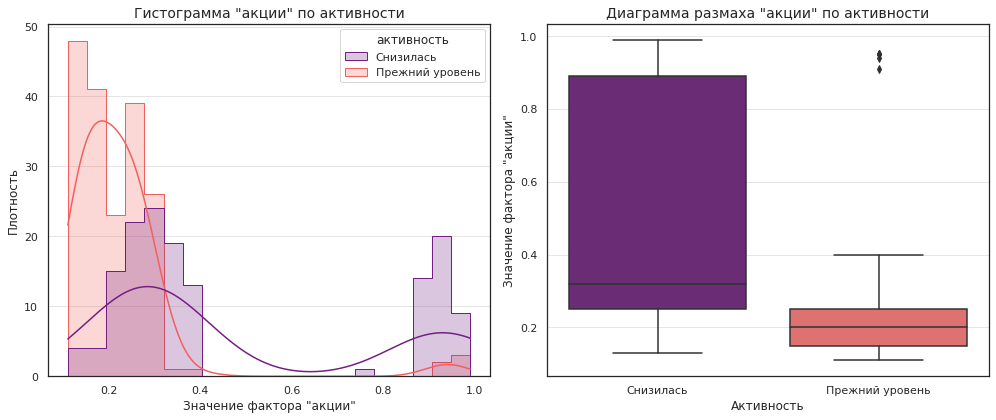

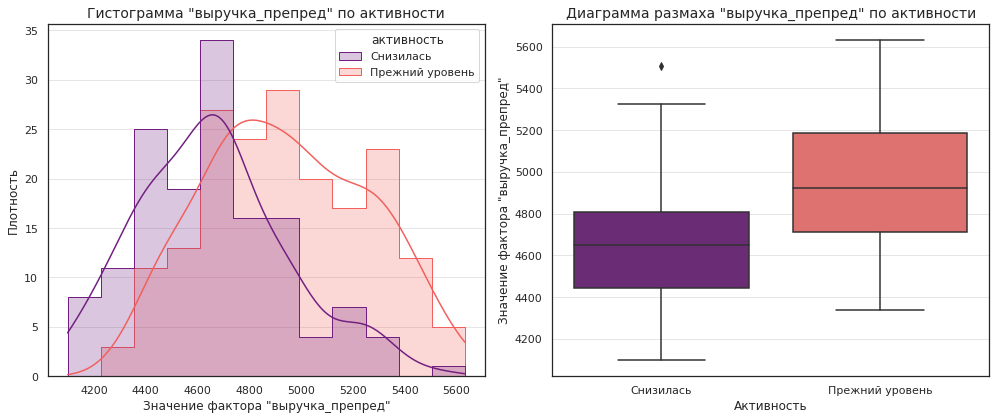

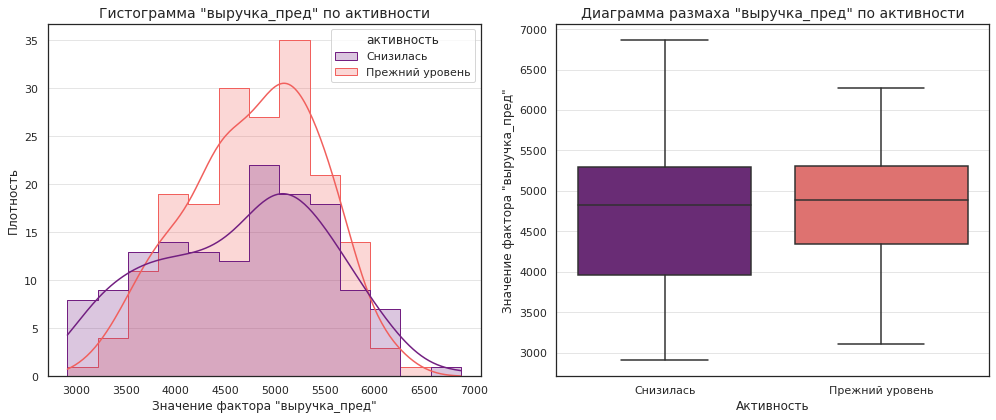

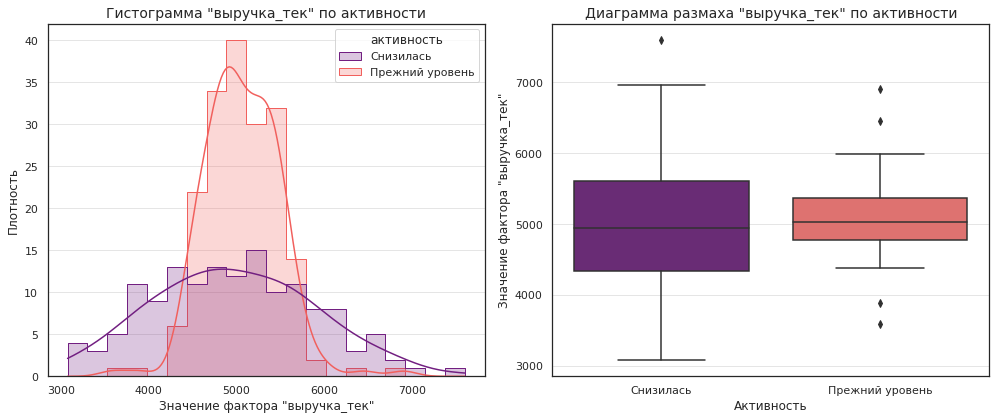

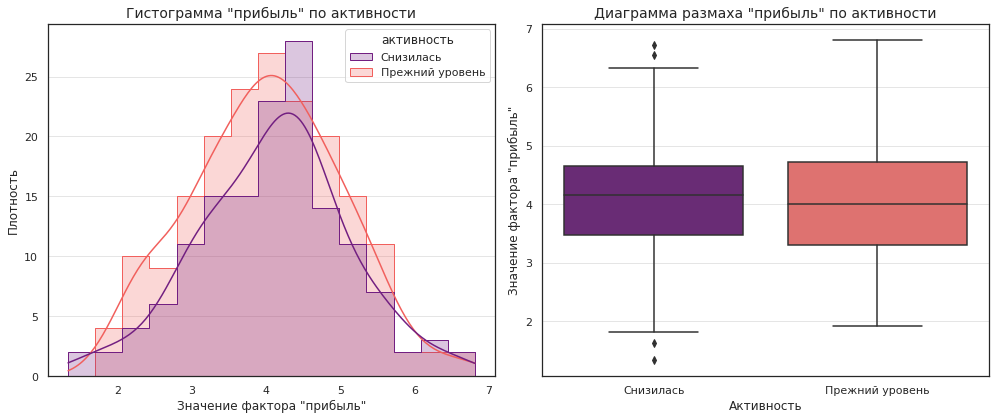

In [67]:
for name in num_data_1:
    hist_box_graph_two(k_market, name)

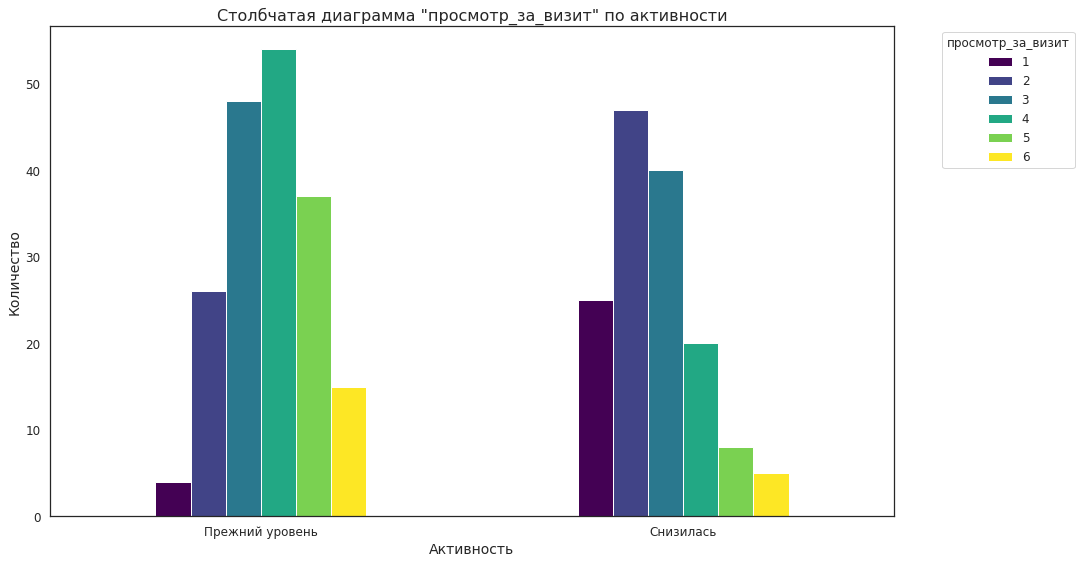

None

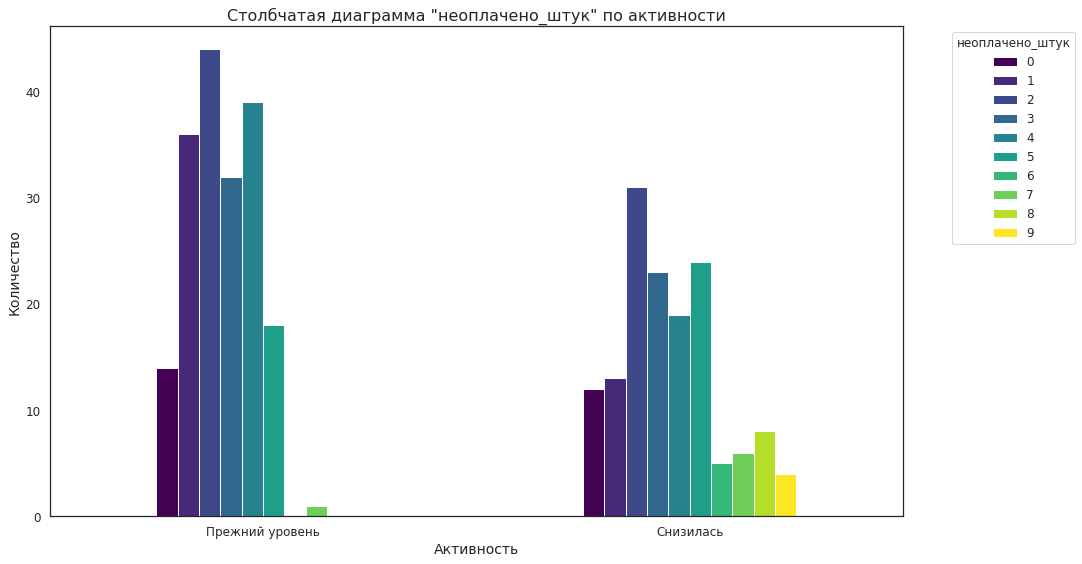

None

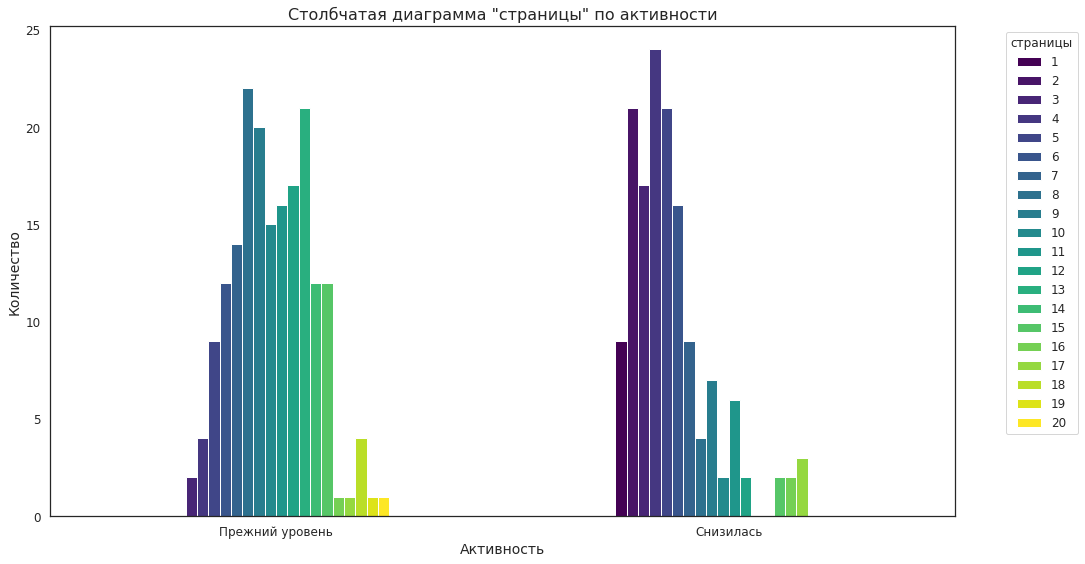

None

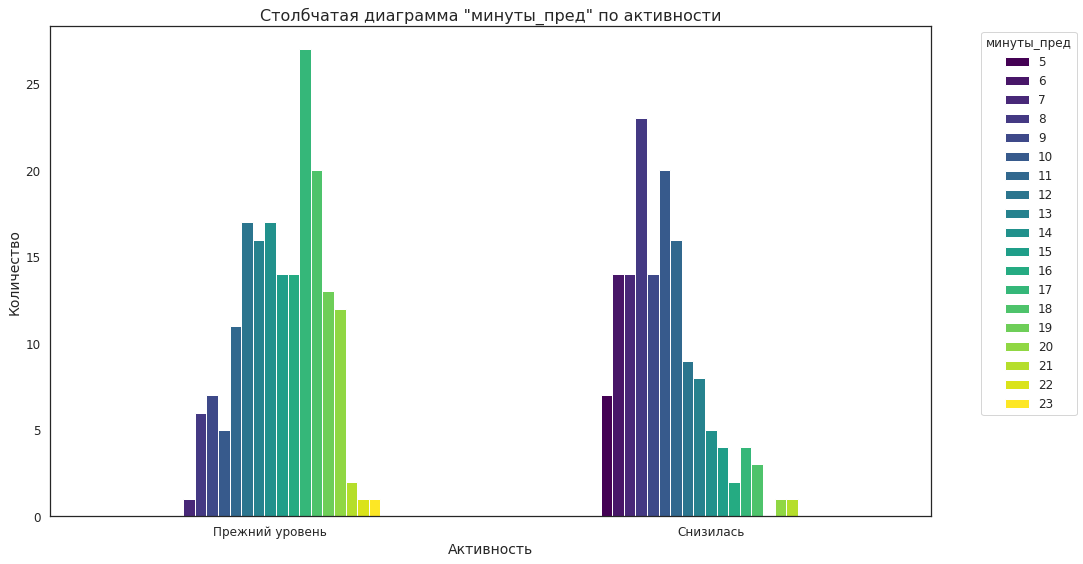

None

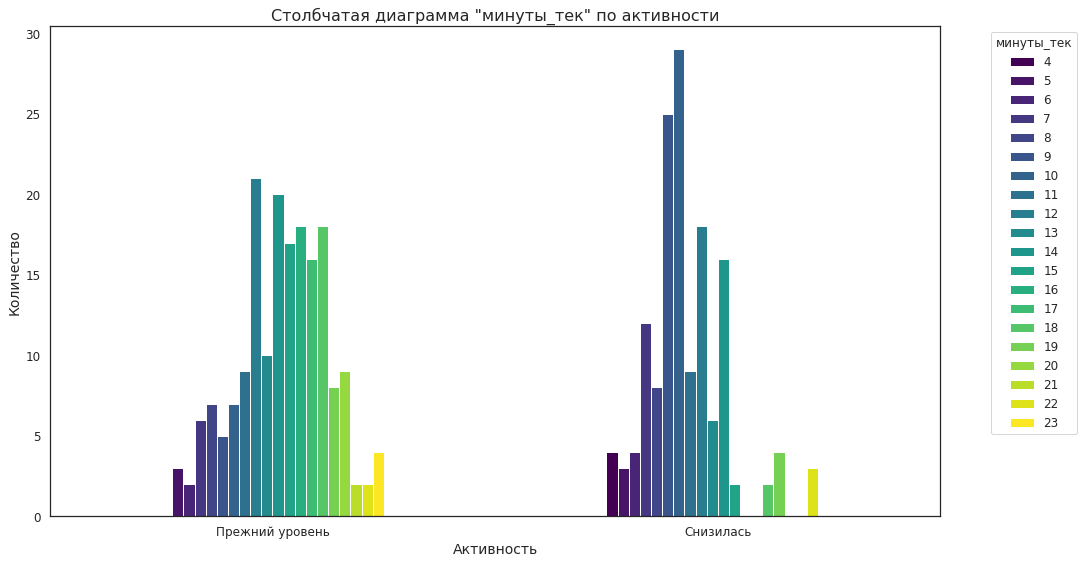

None

In [68]:
for name in dis_data_1:
    display(bar_plot_by_activity(k_market, name))

*Вывод:*  
* Пользователи, которые имеют сниженную активность часто покупают товары категории "Товары для детей" используя акцию. Также они реже просматривают другие категории за время нахождения на сайте, что говорит о том, что они заходят именно ради детских товаров, скорее всего который они уже видели до этого где-то. Ещё они не просматривают много страниц. И что закономерно проводят минимум времени на сайте. 
* Если смотреть на выручку то в последние два месяца пользователи со сниженной активностью практически догнали по ней пользователей с прежнем уровнем (учитывая, что при этом пользователи с прежнем уровнем не стали меньше приносить выручки), что может говорить о росте интереса среди пользователей со сниженной активностью данной категории товаров. Также в среднем пользователи со сниженной активностью приносят больше прибыли чем пользователи с прежней активностью.

*Рекомендация:*  
Учитывая всё выше сказанное, требуется на первых страницах сайта разместить таргетированные под конкретного пользователя акционные листы либо баннеры указывающие, что есть скидки на детские товары. Собрать новые данные и посмотреть результат для корректировки выводов.

## Общий вывод

1. Загрузка данных
* Во всех таблицах пропуски не обнаружены;
* Во всех таблицах корректно обозначен тип данных;
* Требуется проверка на явные и неявные дубликаты;
* Можно привести все названия столбцов к нижнему регистру и использовать аббривеатуры для сокращения длинны текста названия.

2. Предобработка данных
* Были изменены названия столбцов;
* Также было проанализированно - явных дубликатов нет.

3. Исследовательский анализ
* фактор **актив_6_мес** имеет близкое распределение к нормальному. Присутствуют выбросы, которые возможно нужно удалить;
* фактор **актив_тек_мес** судя по визуализации нужно перевести в категориальный, где будет три категории;
* фактор **длительность** не имеет выбросов, имеет близкое распределение к равномерному;
* фактор **акции** имеет бимодальное распределение, также можно отметить, что есть покупатели, которые без акций не покупают;
* фактор **просмотр_за_визит** судя по визуализации нужно перевести в категориальный, где будет 6 категорий;
* фактор **неоплачено_штук** судя по визуализации нужно перевести в категориальный, где будет 11 категорий;
* фактор **ошибки** судя по визуализации нужно перевести в категориальный, где будет 10 категорий;
* фактор **страницы** не имеет выбросов, имеет слегка сдвинутое влево нормальное распределение.
* Выручка имеет распределение близкое к нормальному, также имеются выбросы - пользователи без покупок. В будущем их надо будет исключить.
* Фактор **минуты** имеет близкое к нормальному распределение, выбросов нет.
* Фактор **прибыль** имеет распределение близкое к нормальному, также присутствуют незначительные выбросы.
* факторы **актив_6_мес**, **просмотр_за_визит**, **страницы**, **выручка_препред**, **минуты_пред** и **минуты_тек** в среднем больше у покупателей с прежним уровнем активности, чем у тех у кого снизилась;
* факторы **акции**, **неоплачено_штук** в среднем ниже у покупателей с прежним уровнем активности, чем у тех у кого снизилась активность.
* Соотношение категорий в рассматриваемых факторах практически не изменилось. Самые большие изменения произошли в факторе "категория". При прежней покупательной активности соотношение более равномерное, при снижении покупательной активности основными категориями становятся товары для детей, косметика и аксессуары, домашний текстиль.

4. Корреляционный анализ  
Сильная корреляция наблюдается между факторами **выручка_тек** и **выручка_пред**. Убирать мы их не будем, объединим их в один столбец.  
  
5. Поиск лучшей модели
* Выбрана метрика ROC-AUC, потому что имеется несбалансированность целевого признака. Также его легко интерпретировать.
* Снова самой лучшей моделью была выбрана {'models': SVC(probability=True, random_state=42), 'preprocessor__num': StandardScaler()} с метрикой ROC-AUC для неё 0.910572;
* На тестовой выборке результат чуть лучше 0.911378.

6. Анализ важности факторов
Самый важный признак **длительность** - время с момента регистрации пользователя. Далее идёт **минуты** - время проведённое на сайте и так далее, так ка важность у первых 13 не сильно отличается. Разобъём покупателей по самым важным факторам на сегменты.
   
7. Сегментация пользователей

Перечислим значения факторов свойственных для покупателей со сниженной активностью.
* 'актив_6_мес' меньше 3 месяцев;
* 'акции' больше 0.7;
* 'неоплачено_штук' 6 и более;
* 'страницы' менее 4;
* 'выручка_препред' менее 4400;
* 'минуты_пред' менее 10;
* 'минуты_тек' менее 10.

Можно выделить сегмент покупателей, которые совершают покупки на малую сумму, то есть со значениями фактора "выручка_препред" менее 4400, потому что активность таких покупателей низкая в последнее время.

Большинство пользуется стандартной подпиской, получает рассылку, однако акциями пользуется не большинство. В основном покупают товары для детей и технику для красоты и здоровья. Нужно им рассылать акции на товары для детей и технику для красоты и здоровья.

* Пользователи, которые имеют сниженную активность часто покупают товары категории "Товары для детей" используя акцию. Также они реже просматривают другие категории за время нахождения на сайте, что говорит о том, что они заходят именно ради детских товаров, скорее всего который они уже видели до этого где-то. Ещё они не просматривают много страниц. И что закономерно проводят минимум времени на сайте. 
* Если смотреть на выручку то в последние два месяца пользователи со сниженной активностью практически догнали по ней пользователей с прежнем уровнем (учитывая, что при этом пользователи с прежнем уровнем не стали меньше приносить выручки), что может говорить о росте интереса среди пользователей со сниженной активностью данной категории товаров. Также в среднем пользователи со сниженной активностью приносят больше прибыли чем пользователи с прежней активностью в категории детские товары.

**Рекомендация:**  
Учитывая всё выше сказанное, требуется на первых страницах сайта разместить таргетированные под конкретного пользователя акционные листы либо баннеры указывающие, что есть скидки на детские товары. Впоследствии собрать обновлённые данные и посмотреть результат для корректировки выводов.

Выполнил Лосевский Дмитрий